In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, ParameterGrid, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from scipy.stats import chi2_contingency, ttest_ind
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import os
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", message="`BaseEstimator._validate_data` is deprecated")
warnings.filterwarnings(action='ignore', category=UserWarning, module='xgboost')

In [2]:
def tenure_category(years):
    """Categorizes years at company."""
    if years < 3:
        return 'Short-term'
    elif 3 <= years < 15:
        return 'Medium-term'
    else:
        return 'Long-term'

def salary_band(income):
    """Categorizes monthly income."""
    if income < 4755:
        return 'Low'
    elif 4755 <= income < 10329:
        return 'Medium'
    else:
        return 'High'

# === 2. Data Preprocessing Function (New) ===
# Run this function ONCE before splitting your data

def preprocess_data(data):
    """
    Cleans data and creates new features.
    This should be run before train_test_split.
    """
    # 1. Apply row selection/cleaning
    df = data[~((data["years_at_company"] == 0) & (data.age > 45))].copy()
    
    # 2. Create new features
    if 'years_at_company' in df.columns:
        df['tenure_category'] = df['years_at_company'].apply(tenure_category)
    if 'monthly_income' in df.columns:
        df['salary_band'] = df['monthly_income'].apply(salary_band)
    
    return df

# === 3. FeatureSelector Transformer (Corrected) ===
# This transformer now correctly assumes features are already created.

class FeatureSelector(BaseEstimator, TransformerMixin):
    """
    Selects features using Chi-square and t-tests.
    This transformer should be fit on X and y *after* preprocess_data has been run.
    """
    def __init__(self, target='attrition'):
        self.target = target

    def _Chi_squared_test(self, df):
        """Internal method for Chi-square test."""
        categorical_cols = df.select_dtypes(include=['object', 'category']).columns
        results = []
        for col in categorical_cols:
            if col != self.target:
                try:
                    contingency_table = pd.crosstab(df[col], df[self.target])
                    chi2, p, dof, expected = chi2_contingency(contingency_table)
                    if p < 0.05:
                        results.append(col)
                except ValueError:
                    # Handle cases with only one category after splits
                    continue
        return results

    def _t_test_feature_selection(self, df):
        """Internal method for t-test."""
        numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
        groups = df[self.target].unique()
        if len(groups) != 2:
            return []  # Can't perform t-test
        
        results = []
        group1_name, group2_name = groups
        
        for col in numeric_cols:
            g1 = df[df[self.target] == group1_name][col].dropna()
            g2 = df[df[self.target] == group2_name][col].dropna()
            
            # Need at least 2 samples in each group to perform a t-test
            if g1.nunique() > 1 and g2.nunique() > 1:
                _, p = ttest_ind(g1, g2, equal_var=False)
                if p < 0.05:
                    results.append(col)
        return results

    def fit(self, X, y=None):
        if y is None:
            raise ValueError("y (target) must be provided during fit().")
        
        # Temporarily combine X and y to perform statistical tests
        df = X.copy()
        df[self.target] = y

        chi_features = self._Chi_squared_test(df)
        ttest_features = self._t_test_feature_selection(df)
        
        # Combine lists and remove duplicates
        self.selected_features_ = list(dict.fromkeys(chi_features + ttest_features))
        
        if not self.selected_features_:
            print("Warning: No features were selected. Check data and p-value thresholds.")
            
        return self

    def transform(self, X):
        df = X.copy()
        # Return only the columns selected during fit
        return df[self.selected_features_]

# === 4. Encoder Transformer (Corrected) ===
# This transformer now safely uses OneHotEncoder instead of pd.get_dummies.

class LabelOneHotEncoder(BaseEstimator, TransformerMixin):
    """
    Applies LabelEncoding to specified ordinal columns and
    OneHotEncoding to specified nominal columns.
    """
    def __init__(self):
        # Define all *potential* columns to encode
        self.label_encode_cols_list = [
            'work_life_balance', 'job_satisfaction', 'overtime', 'job_level',
            'company_size', 'leadership_opportunities', 'company_reputation',
            'employee_recognition', 'age_groups', 'education_level',
            'attrition', 'tenure_category', 'salary_band'
        ]
        self.onehot_encode_cols_list = ['job_role', 'marital_status', 'gender']
    
    def fit(self, X, y=None):
        # Filter lists based on columns that are *actually in X*
        self.label_encode_cols_ = [col for col in self.label_encode_cols_list if col in X.columns]
        self.onehot_encode_cols_ = [col for col in self.onehot_encode_cols_list if col in X.columns]
        
        # 1. Fit LabelEncoders
        self.label_encoders_ = {}
        for col in self.label_encode_cols_:
            le = LabelEncoder()
            le.fit(X[col].astype(str))
            self.label_encoders_[col] = le
            
        # 2. Fit OneHotEncoder
        if self.onehot_encode_cols_:
            self.onehot_encoder_ = OneHotEncoder(
                drop='first',              # Matches pd.get_dummies(drop_first=True)
                sparse_output=False,       # Returns a dense array
                handle_unknown='ignore'    # Prevents errors on test data
            )
            self.onehot_encoder_.fit(X[self.onehot_encode_cols_].astype(str))
        
        return self
        
    def transform(self, X):
        df = X.copy()
        
        # 1. Apply LabelEncoding
        for col, le in self.label_encoders_.items():
            df[col] = le.transform(df[col].astype(str))
        
        # 2. Apply OneHotEncoding
        if self.onehot_encode_cols_ and hasattr(self, 'onehot_encoder_'):
            # Transform data
            ohe_data = self.onehot_encoder_.transform(df[self.onehot_encode_cols_].astype(str))
            
            # Get new column names
            ohe_cols = self.onehot_encoder_.get_feature_names_out(self.onehot_encode_cols_)
            
            # Create a DataFrame for the new OHE columns
            ohe_df = pd.DataFrame(ohe_data, columns=ohe_cols, index=df.index)
            
            # Drop the original nominal columns
            df = df.drop(columns=self.onehot_encode_cols_)
            
            # Concatenate original df with new OHE df
            df = pd.concat([df, ohe_df], axis=1)
        
        # Convert all columns to float for modeling
        df = df.astype(float)
        return df

In [3]:
df_train = pd.read_csv("../../data/Faker_Data/train.csv")
df_test = pd.read_csv("../../data/Faker_Data/test.csv")

In [4]:
X_train = df_train.drop('attrition', axis=1)
y_train = df_train['attrition']
X_test = df_test.drop('attrition', axis=1)
y_test = df_test['attrition']

# Encode target variable
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)
print(f"Target classes: {target_encoder.classes_}")
print(f"Encoded as: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")

Target classes: ['Left' 'Stayed']
Encoded as: {'Left': np.int64(0), 'Stayed': np.int64(1)}


In [5]:
standard_scale_cols = ["age"]
minmax_scale_cols = ["years_at_company", "monthly_income", "number_of_promotions"]

In [6]:
# === Pipeline ===
standard_transformer = Pipeline([("standard_scaler", StandardScaler())])

minmax_transformer = Pipeline([("minmax_scaler", MinMaxScaler())])

preprocessor = ColumnTransformer(
    transformers=[
        ("standard", standard_transformer, standard_scale_cols),
        ("minmax", minmax_transformer, minmax_scale_cols),
    ],
    remainder="passthrough",
)

# --- your custom feature selection and encoding steps (from before) ---
pre_base = Pipeline(
    [("feature_selection", FeatureSelector()), ("encoding", LabelOneHotEncoder())]
)

# --- final full preprocessing pipeline ---
preprocessing_pipeline = Pipeline(
    [("feature_selection_encoding", pre_base), ("scaling", preprocessor)]
)

In [12]:
# === Models & Grid Params ===
models = {
    "RandomForest": (RandomForestClassifier(random_state=42, max_features='sqrt'), {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [10, 15, 20],
        'classifier__min_samples_split': [10, 20],
        'classifier__min_samples_leaf': [4, 8]
    }),
    "KNN": (KNeighborsClassifier(), {
        'classifier__n_neighbors': [3, 5, 7],
        'classifier__weights': ['uniform', 'distance']
    }),
    "XGBoost": (XGBClassifier(eval_metric='logloss', random_state=42), {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.05, 0.1, 0.2]
    })
}


🔹 Training RandomForest with Grid Search + SMOTE...
🔧 Building pipeline components...
📈 Initializing GridSearchCV...
🧠 Training RandomForest model with grid search (this may take a while)...


Training RandomForest:   0%|          | 0/1

Fitting 3 folds for each of 24 candidates, totalling 72 fits
✅ Finished training RandomForest in 6.47 minutes.
🔍 Evaluating model on test set...
✅ Best Params for RandomForest: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
📊 Accuracy: 0.890 | F1-score: 0.890
              precision    recall  f1-score   support

        Left       0.85      0.82      0.83      6016
      Stayed       0.91      0.93      0.92     11984

    accuracy                           0.89     18000
   macro avg       0.88      0.87      0.88     18000
weighted avg       0.89      0.89      0.89     18000



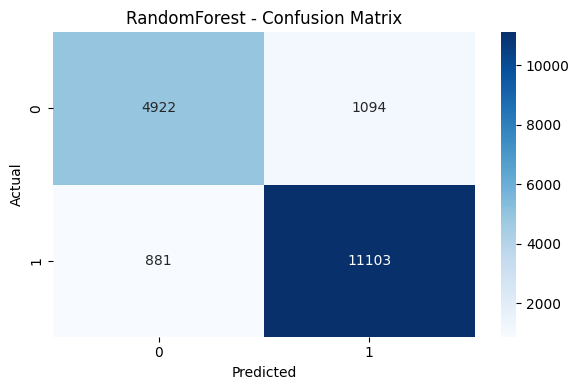

------------------------------------------------------------

🔹 Training KNN with Grid Search + SMOTE...
🔧 Building pipeline components...
📈 Initializing GridSearchCV...
🧠 Training KNN model with grid search (this may take a while)...


Training KNN:   0%|          | 0/1

Fitting 3 folds for each of 6 candidates, totalling 18 fits
✅ Finished training KNN in 1.97 minutes.
🔍 Evaluating model on test set...
✅ Best Params for KNN: {'classifier__n_neighbors': 7, 'classifier__weights': 'distance'}
📊 Accuracy: 0.853 | F1-score: 0.854
              precision    recall  f1-score   support

        Left       0.75      0.83      0.79      6016
      Stayed       0.91      0.86      0.89     11984

    accuracy                           0.85     18000
   macro avg       0.83      0.85      0.84     18000
weighted avg       0.86      0.85      0.85     18000



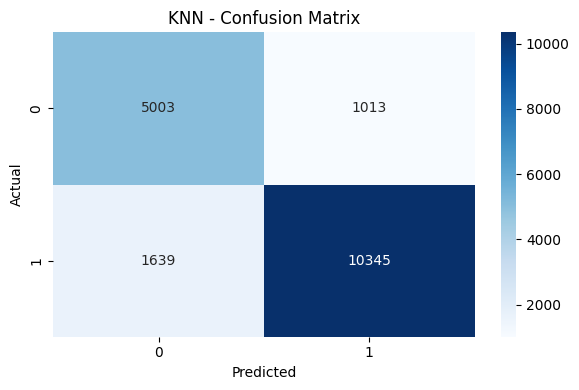

------------------------------------------------------------

🔹 Training XGBoost with Grid Search + SMOTE...
🔧 Building pipeline components...
📈 Initializing GridSearchCV...
🧠 Training XGBoost model with grid search (this may take a while)...


Training XGBoost:   0%|          | 0/1

Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Finished training XGBoost in 1.75 minutes.
🔍 Evaluating model on test set...
✅ Best Params for XGBoost: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
📊 Accuracy: 0.896 | F1-score: 0.895
              precision    recall  f1-score   support

        Left       0.87      0.81      0.84      6016
      Stayed       0.91      0.94      0.92     11984

    accuracy                           0.90     18000
   macro avg       0.89      0.88      0.88     18000
weighted avg       0.90      0.90      0.90     18000



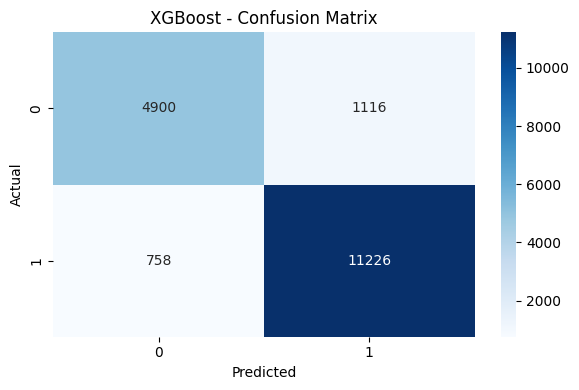

------------------------------------------------------------


Exception ignored in: <function ResourceTracker.__del__ at 0x7f40c638c040>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f79d6090040>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f8e51080040>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/reso

In [ ]:
from tqdm.auto import tqdm
import time
import datetime

# === Training & Evaluation ===
for name, (clf, params) in models.items():
    print(f"\n🔹 Training {name} with Grid Search + SMOTE...")
    print("🔧 Building pipeline components...")
    time.sleep(0.5)
    # Create pipeline with proper ordering
    pipeline = ImbPipeline(steps=[
        ("feature_selection", FeatureSelector(target='attrition')),
        ("encoding", LabelOneHotEncoder()),
        ("scaling", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", clf)
    ])
    
    print("📈 Initializing GridSearchCV...")
    grid = GridSearchCV(
        pipeline,
        param_grid=params,
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print(f"🧠 Training {name} model with grid search (this may take a while)...")
    start_time = time.time()

    with tqdm(total=1, desc=f"Training {name}", bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt}') as pbar:
        grid.fit(X_train, y_train)
        pbar.update(1)

    duration = time.time() - start_time
    print(f"✅ Finished training {name} in {duration/60:.2f} minutes.")

    print("🔍 Evaluating model on test set...")
    preds = grid.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')

    print(f"✅ Best Params for {name}: {grid.best_params_}")
    print(f"📊 Accuracy: {acc:.3f} | F1-score: {f1:.3f}")
    print(classification_report(y_test, preds, target_names=target_encoder.classes_))

    # # === Save Model ===
    filename = f"{name}_best_model.pkl"
    with open(filename, "wb") as file:
        pickle.dump(grid.best_estimator_, file)
    
    # Get file size
    import os
    file_size_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"💾 Saved {name} model as {filename} ({file_size_mb:.2f} MB)")

    # === Confusion Matrix ===
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    print("-" * 60)


🔹 Training RandomForest with Grid Search + SMOTE...
🔧 Building pipeline components...
📊 Total parameter combinations: 24


Training RandomForest:   0%|          | 0/24 [00:00<?, ?comb/s]

✅ Finished training RandomForest.
🔍 Best F1-score: 0.892
✅ Best Params for RandomForest: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 100}
📊 Accuracy: 0.891 | F1-score: 0.890
              precision    recall  f1-score   support

        Left       0.85      0.82      0.83      6016
      Stayed       0.91      0.93      0.92     11984

    accuracy                           0.89     18000
   macro avg       0.88      0.87      0.88     18000
weighted avg       0.89      0.89      0.89     18000



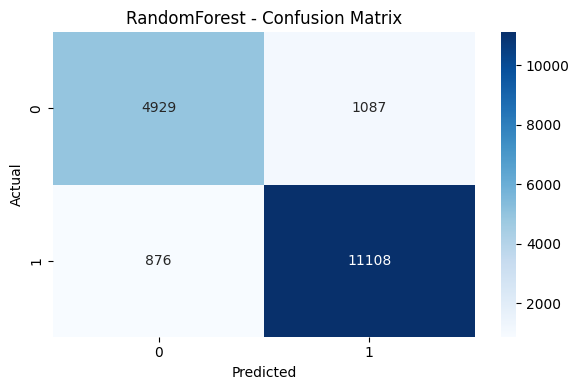

------------------------------------------------------------

🔹 Training KNN with Grid Search + SMOTE...
🔧 Building pipeline components...
📊 Total parameter combinations: 6


Training KNN:   0%|          | 0/6 [00:00<?, ?comb/s]

✅ Finished training KNN.
🔍 Best F1-score: 0.854
✅ Best Params for KNN: {'classifier__n_neighbors': 7, 'classifier__weights': 'distance'}
📊 Accuracy: 0.853 | F1-score: 0.854
              precision    recall  f1-score   support

        Left       0.75      0.83      0.79      6016
      Stayed       0.91      0.86      0.89     11984

    accuracy                           0.85     18000
   macro avg       0.83      0.85      0.84     18000
weighted avg       0.86      0.85      0.85     18000



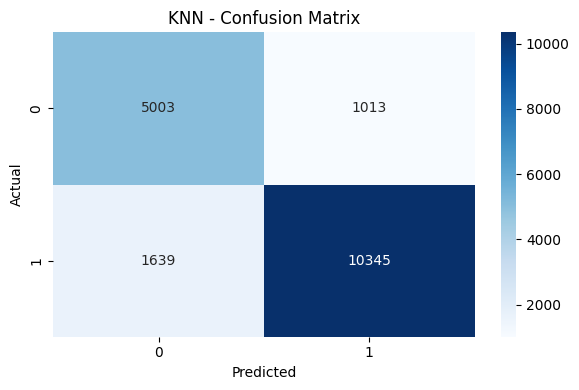

------------------------------------------------------------

🔹 Training XGBoost with Grid Search + SMOTE...
🔧 Building pipeline components...
📊 Total parameter combinations: 18


Training XGBoost:   0%|          | 0/18 [00:00<?, ?comb/s]

✅ Finished training XGBoost.
🔍 Best F1-score: 0.895
✅ Best Params for XGBoost: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}
📊 Accuracy: 0.891 | F1-score: 0.890
              precision    recall  f1-score   support

        Left       0.86      0.81      0.83      6016
      Stayed       0.91      0.93      0.92     11984

    accuracy                           0.89     18000
   macro avg       0.88      0.87      0.88     18000
weighted avg       0.89      0.89      0.89     18000



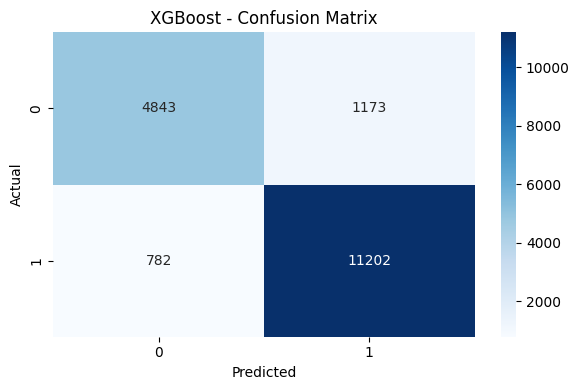

------------------------------------------------------------


In [31]:
from tqdm.auto import tqdm
import time

# === Training & Evaluation with tqdm per param combination ===
for name, (clf, params) in models.items():
    print(f"\n🔹 Training {name} with Grid Search + SMOTE...")
    print("🔧 Building pipeline components...")
    time.sleep(0.5)

    # Create pipeline
    pipeline = ImbPipeline(steps=[
        ("feature_selection", FeatureSelector(target='attrition')),
        ("encoding", LabelOneHotEncoder()),
        ("scaling", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", clf)
    ])

    # Prepare parameter combinations
    param_grid_list = list(ParameterGrid(params))
    total_combinations = len(param_grid_list)
    print(f"📊 Total parameter combinations: {total_combinations}")

    # Initialize tqdm bar
    with tqdm(total=total_combinations, desc=f"Training {name}", unit="comb") as pbar:
        best_score = 0
        best_params = None
        best_model = None

        for single_params in param_grid_list:
            # Update pipeline parameters
            pipeline.set_params(**single_params)
            pipeline.fit(X_train, y_train)

            # Evaluate on validation set (optional, here we use train)
            preds = pipeline.predict(X_test)
            f1 = f1_score(y_test, preds, average='weighted')

            # Track best model
            if f1 > best_score:
                best_score = f1
                best_params = single_params
                best_model = pipeline

            pbar.update(1)

    print(f"✅ Finished training {name}.")
    print(f"🔍 Best F1-score: {best_score:.3f}")
    print(f"✅ Best Params for {name}: {best_params}")

    # Evaluate final model
    preds = best_model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    print(f"📊 Accuracy: {acc:.3f} | F1-score: {f1:.3f}")
    print(classification_report(y_test, preds, target_names=target_encoder.classes_))


    # # === Save Model ===
    # filename = f"{name}_best_model.pkl"
    # with open(filename, "wb") as file:
    #     pickle.dump(grid.best_estimator_, file)
    
    # # Get file size
    # import os
    # file_size_mb = os.path.getsize(filename) / (1024 * 1024)
    # print(f"💾 Saved {name} model as {filename} ({file_size_mb:.2f} MB)")
    

    # Confusion matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    print("-" * 60)


🔹 Training RandomForest with Grid Search + SMOTE...
🔧 Building pipeline components...
📊 Total parameter combinations: 24 with 3 folds each


Training RandomForest:   0%|          | 0/72 [00:00<?, ?fold/s]

✅ Finished training RandomForest.
🔍 Best F1-score (CV average): 0.888
✅ Best Params for RandomForest: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
📊 Test Accuracy: 0.892 | Test F1-score: 0.891
              precision    recall  f1-score   support

        Left       0.86      0.81      0.83      6016
      Stayed       0.91      0.93      0.92     11984

    accuracy                           0.89     18000
   macro avg       0.88      0.87      0.88     18000
weighted avg       0.89      0.89      0.89     18000



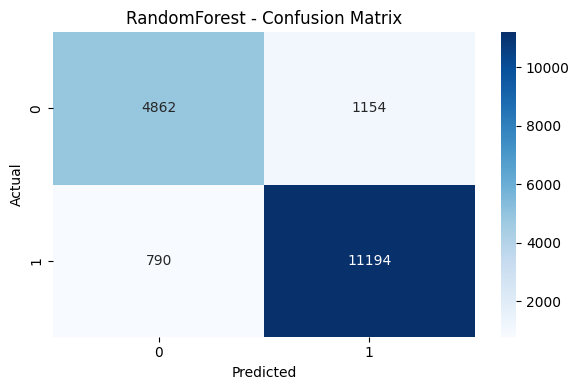

------------------------------------------------------------

🔹 Training KNN with Grid Search + SMOTE...
🔧 Building pipeline components...
📊 Total parameter combinations: 6 with 3 folds each


Training KNN:   0%|          | 0/18 [00:00<?, ?fold/s]

✅ Finished training KNN.
🔍 Best F1-score (CV average): 0.847
✅ Best Params for KNN: {'classifier__n_neighbors': 7, 'classifier__weights': 'uniform'}
📊 Test Accuracy: 0.832 | Test F1-score: 0.834
              precision    recall  f1-score   support

        Left       0.71      0.84      0.77      6016
      Stayed       0.91      0.83      0.87     11984

    accuracy                           0.83     18000
   macro avg       0.81      0.83      0.82     18000
weighted avg       0.84      0.83      0.83     18000



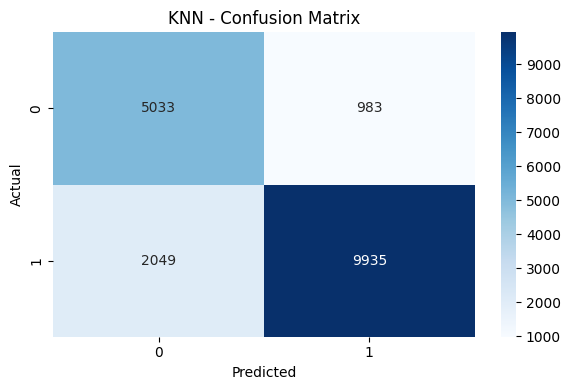

------------------------------------------------------------

🔹 Training XGBoost with Grid Search + SMOTE...
🔧 Building pipeline components...
📊 Total parameter combinations: 18 with 3 folds each


Training XGBoost:   0%|          | 0/54 [00:00<?, ?fold/s]

✅ Finished training XGBoost.
🔍 Best F1-score (CV average): 0.894
✅ Best Params for XGBoost: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
📊 Test Accuracy: 0.891 | Test F1-score: 0.890
              precision    recall  f1-score   support

        Left       0.86      0.80      0.83      6016
      Stayed       0.90      0.94      0.92     11984

    accuracy                           0.89     18000
   macro avg       0.88      0.87      0.88     18000
weighted avg       0.89      0.89      0.89     18000



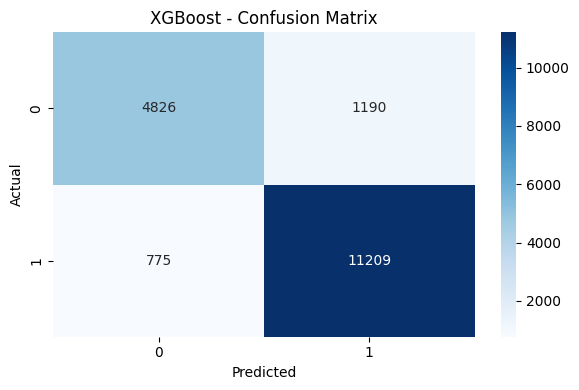

------------------------------------------------------------


In [10]:
from tqdm.auto import tqdm
import time

# === Training & Evaluation with fold-level tqdm ===
cv_folds = 3  # Number of CV folds

for name, (clf, params) in models.items():
    print(f"\n🔹 Training {name} with Grid Search + SMOTE...")
    print("🔧 Building pipeline components...")
    time.sleep(0.5)

    # Create pipeline
    pipeline = ImbPipeline(steps=[
        ("feature_selection", FeatureSelector(target='attrition')),
        ("encoding", LabelOneHotEncoder()),
        ("scaling", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", clf)
    ])

    # Prepare parameter combinations
    param_grid_list = list(ParameterGrid(params))
    total_combinations = len(param_grid_list)
    total_steps = total_combinations * cv_folds  # total iterations for tqdm

    print(f"📊 Total parameter combinations: {total_combinations} with {cv_folds} folds each")

    # Initialize tqdm bar for all folds
    with tqdm(total=total_steps, desc=f"Training {name}", unit="fold") as pbar:
        best_score = 0
        best_params = None
        best_model = None

        for single_params in param_grid_list:
            # Update pipeline parameters
            pipeline.set_params(**single_params)

            # Cross-validation manually
            kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
            fold_scores = []

            for train_idx, val_idx in kf.split(X_train):
                X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_tr, y_val = y_train[train_idx], y_train[val_idx]

                pipeline.fit(X_tr, y_tr)
                val_preds = pipeline.predict(X_val)
                fold_f1 = f1_score(y_val, val_preds, average='weighted')
                fold_scores.append(fold_f1)

                pbar.update(1)  # update after each fold

            # Average F1-score across folds
            mean_f1 = sum(fold_scores) / cv_folds

            # Track best model
            if mean_f1 > best_score:
                best_score = mean_f1
                best_params = single_params
                best_model = pipeline

    print(f"✅ Finished training {name}.")
    print(f"🔍 Best F1-score (CV average): {best_score:.3f}")
    print(f"✅ Best Params for {name}: {best_params}")

    # Evaluate final model on test set
    preds = best_model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    print(f"📊 Test Accuracy: {acc:.3f} | Test F1-score: {f1:.3f}")
    print(classification_report(y_test, preds, target_names=target_encoder.classes_))

    
    ## === Save Model ===
    # filename = f"{name}_best_model.pkl"
    # with open(filename, "wb") as file:
    #     pickle.dump(grid.best_estimator_, file)
    
    # # Get file size
    # import os
    # file_size_mb = os.path.getsize(filename) / (1024 * 1024)
    # print(f"💾 Saved {name} model as {filename} ({file_size_mb:.2f} MB)")

    
    # Confusion matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    print("-" * 60)